# Midi Analysis

In [36]:
from pathlib import Path
from pretty_midi import PrettyMIDI

import pandas as pd
import matplotlib.pyplot as plt
import IPython
import seaborn as sns

## Load Data

In [37]:
# Paths
data_path = Path.cwd().parent / 'Data'
dl_mb = data_path / 'drumlearning' / 'drumlearning_basti'
dl_f = data_path / 'drumlearning' / 'drumlearning_foundational'
groove = data_path / 'e-gmd-v1.0.0'

In [38]:
# print paths
print(dl_mb)
print(dl_f)
print(groove)

C:\Users\minem\PycharmProjects\ITS-M\Master\GroovePal\Data\drumlearning\drumlearning_basti
C:\Users\minem\PycharmProjects\ITS-M\Master\GroovePal\Data\drumlearning\drumlearning_foundational
C:\Users\minem\PycharmProjects\ITS-M\Master\GroovePal\Data\e-gmd-v1.0.0


In [39]:
meta_dl_mb = dl_mb / 'info.txt'
meta_dl_f = dl_f / 'info.txt'

meta_mb = pd.read_csv(meta_dl_mb, sep='\t', header=None, names=['file', 'name', 'bpm', 'type'], index_col=0)
meta_f = pd.read_csv(meta_dl_f, sep='\t', header=None, names=['file', 'style', 'bpm', 'type'], index_col=0)

In [40]:
# cleaning
meta_mb['bpm'] = meta_mb['bpm'].apply(lambda x: int(x.split(' ')[0]))
meta_mb['bpm'] = meta_mb['bpm'].astype(int)

meta_f['bpm'] = meta_f['bpm'].apply(lambda x: int(x.split(' ')[0]))
meta_f['bpm'] = meta_f['bpm'].astype(int)

In [41]:
meta_mb.head()

,file,name,bpm,type
0,1_1.mid,Bark_1A,120,Pickup
1,1_2.mid,Bark_1A,120,CountIn
2,1_3.mid,Bark_1A,120,IntroPlay | Verse | Chorus
3,1_4.mid,Bark_1A,120,Verse | Bridge
4,1_5.mid,Bark_1A,120,IntroPlay | Verse | Chorus


In [42]:
meta_f.head()

,file,style,bpm,type
0,Variation_01.mid,METALHEADS,98,FULL_SONG
1,Variation_01.mid,METALHEADS,98,THEME
2,Variation_02.mid,METALHEADS,98,THEME
3,Variation_03.mid,METALHEADS,98,THEME
4,Variation_04.mid,METALHEADS,98,THEME


## Meta Analysis

### BPM Distribution

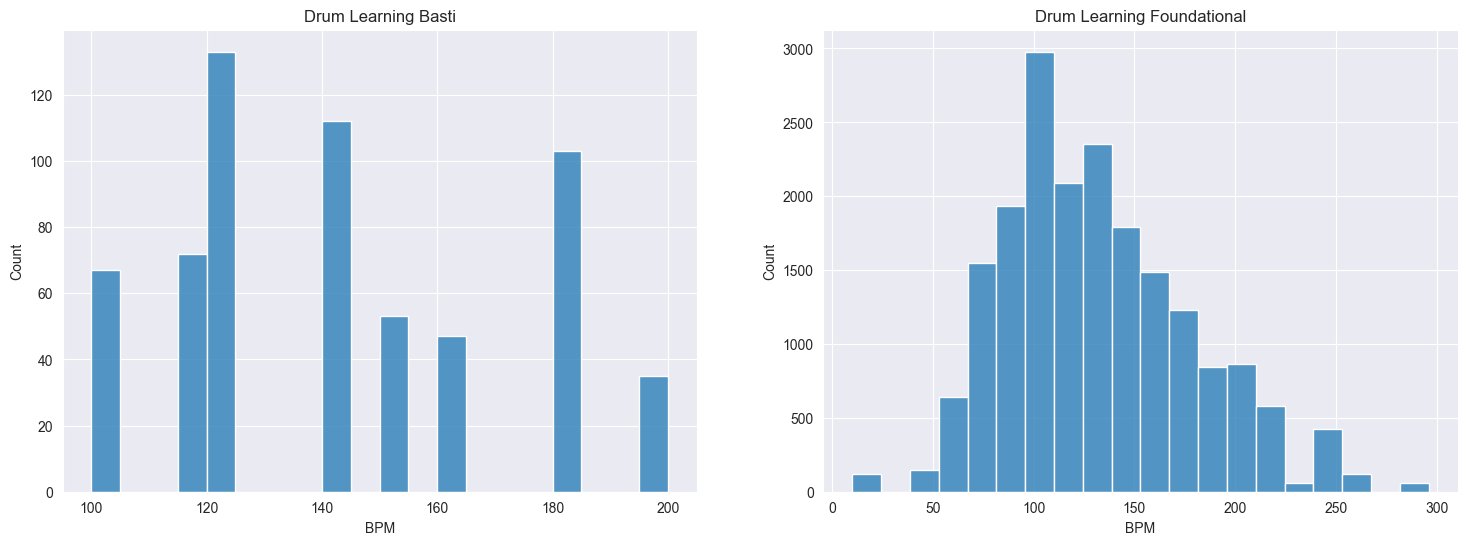

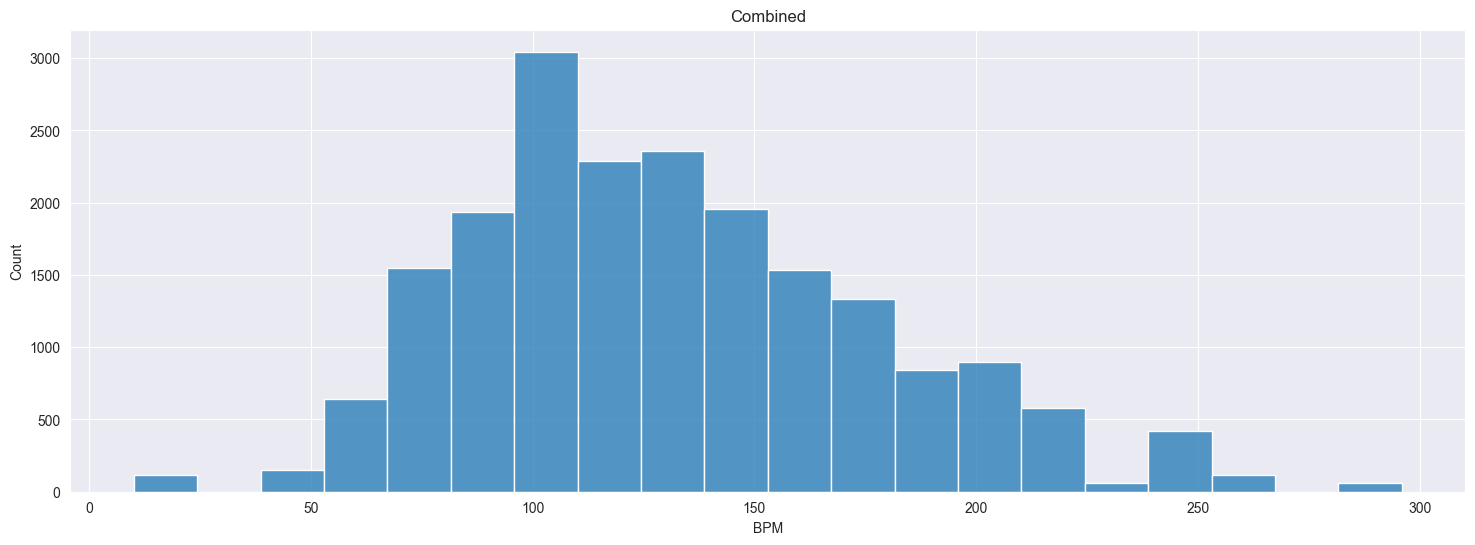

In [43]:
# Plot the distribution of BPMs in each dataset and together
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(meta_mb['bpm'], bins=20, ax=ax[0])
ax[0].set_title('Drum Learning Basti')
ax[0].set_xlabel('BPM')
ax[0].set_ylabel('Count')

sns.histplot(meta_f['bpm'], bins=20, ax=ax[1])
ax[1].set_title('Drum Learning Foundational')
ax[1].set_xlabel('BPM')
ax[1].set_ylabel('Count')

plt.show()

combined = pd.concat([meta_mb['bpm'], meta_f['bpm']])

fig, ax = plt.subplots(1, 1, figsize=(18, 6))
sns.histplot(combined, bins=20, ax=ax)
ax.set_title('Combined')
ax.set_xlabel('BPM')
ax.set_ylabel('Count')


plt.show()

### Style Distribution

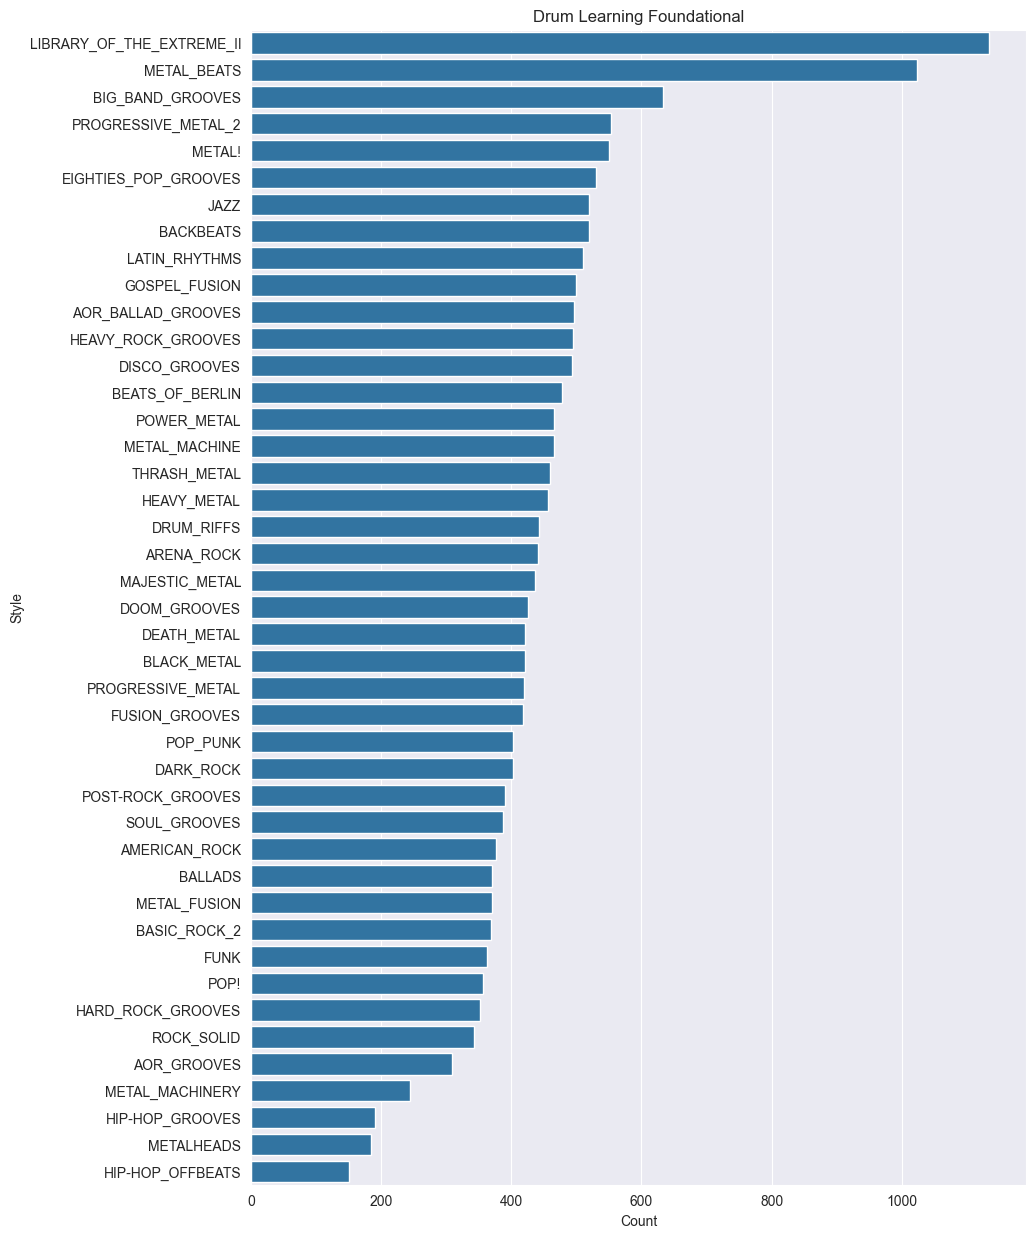

In [44]:
# Plot the distribution of styles in foundational dataset

fig, ax = plt.subplots(1, 1, figsize=(10, 15))
sns.countplot(data=meta_f, y='style', order=meta_f['style'].value_counts().index, ax=ax)
ax.set_title('Drum Learning Foundational')
ax.set_ylabel('Style')
ax.set_xlabel('Count')

plt.show()

### Section Type Distribution

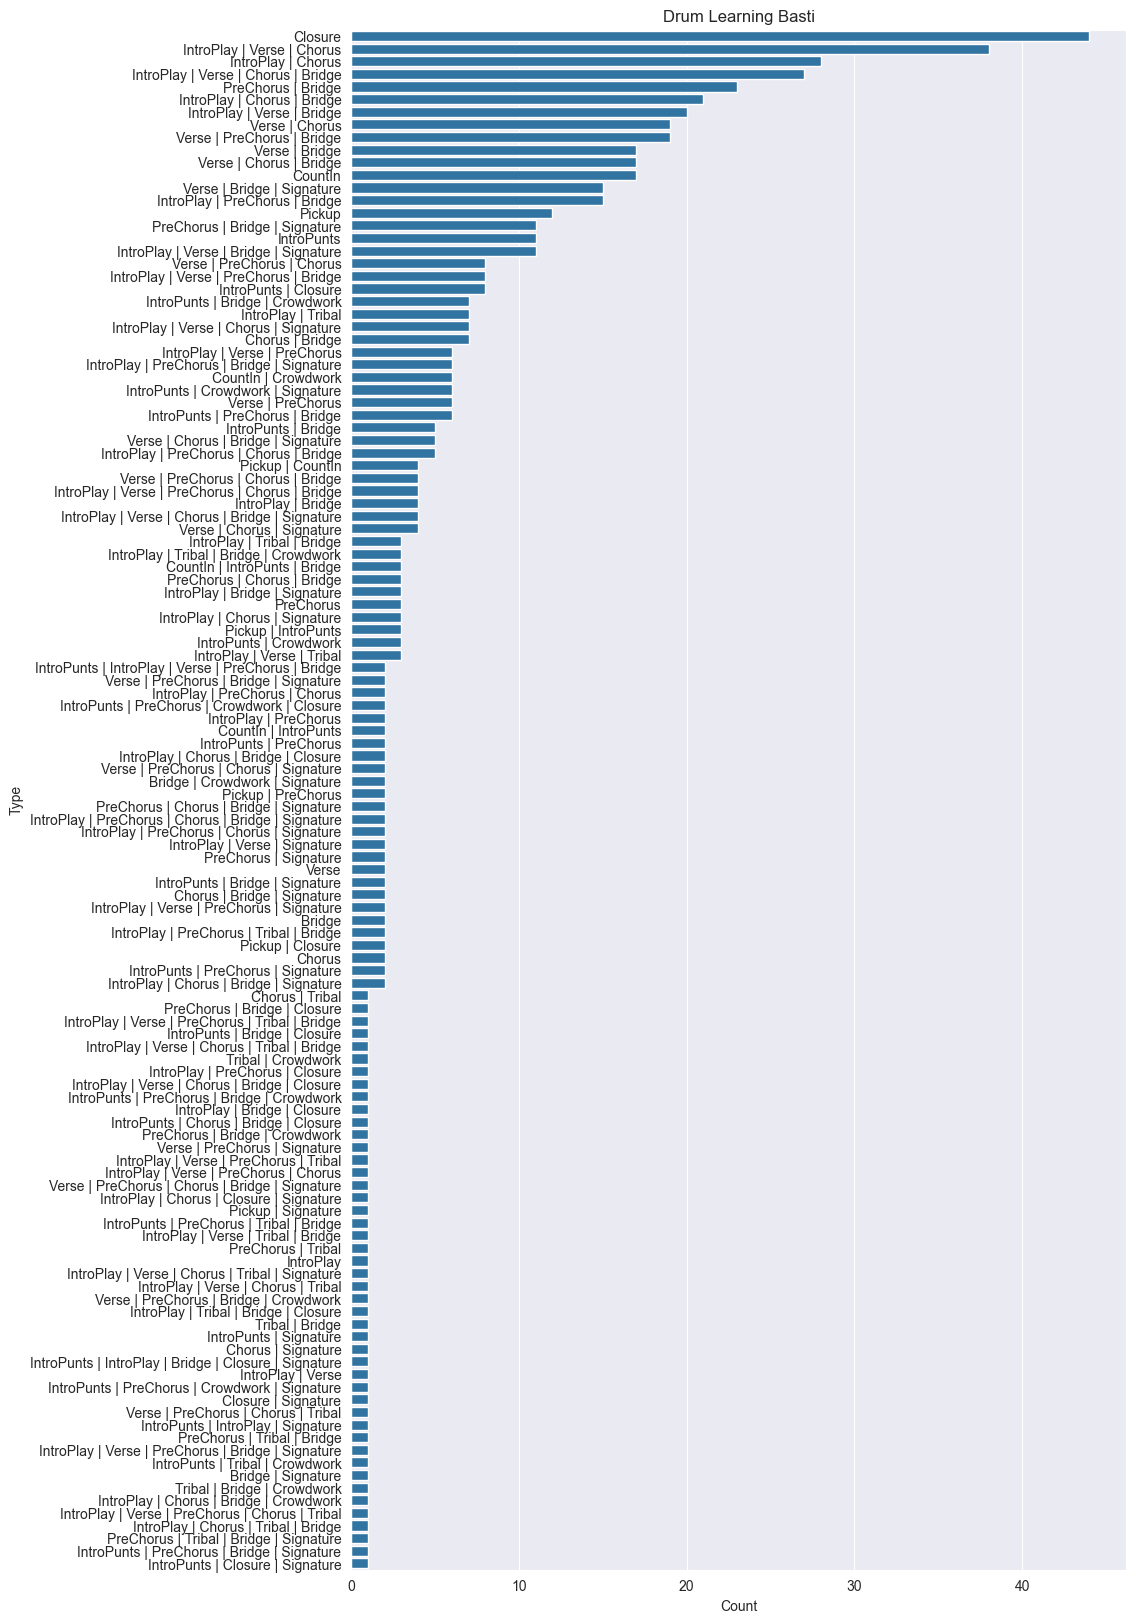

In [45]:
# Plot the distribution of types in basti
fig, ax = plt.subplots(1, 1, figsize=(10, 20))
sns.countplot(data=meta_mb, y='type', order=meta_mb['type'].value_counts().index, ax=ax)
ax.set_title('Drum Learning Basti')
ax.set_ylabel('Type')
ax.set_xlabel('Count')

plt.show()

In [46]:
# All section labels by counts
section_labels = meta_mb['type'].str.split('|').explode().str.strip().value_counts()
section_labels

type
Bridge        322
Verse         269
IntroPlay     266
Chorus        236
PreChorus     176
Signature     117
IntroPunts     75
Closure        69
Crowdwork      37
Tribal         37
CountIn        32
Pickup         24
Name: count, dtype: int64

In [47]:
meta_mb.isna().sum()
# get na files
meta_mb[meta_mb['type'].isna()]

,file,name,bpm,type
103,1_104.mid,Bark_1I,120,NaN
289,3_54.mid,Bark_3B,100,NaN


In [48]:
meta_mb.fillna('Unknown', inplace=True)

In [70]:
meta_mb[meta_mb['file'] == '2_16.mid']

,file,name,bpm,type
148,2_16.mid,Bark_2A,180,PreChorus | Bridge


## Midi Analysis

- instruments (distribution)
- deviation from quantization (microtimings)
- tempo changes
- instrument distribution
- plot drum rolls with zoom function
- how many notes in total / average per file / per instrument -> distribution
- time signatures
- similar instruments -> group them
- patterns in sequences

In [81]:
# x ticks spaced by quantization / beats
def s_to_beats(s, bpm):
    return s * bpm / 60

def beats_to_s(beats, bpm):
    return beats * 60 / bpm

def plot_drum_roll(midi_file):
    # Load the MIDI file
    midi_data = PrettyMIDI(str(midi_file))

    # Extract percussion instrument (drums)
    drum_roll = []
    for instrument in midi_data.instruments:
        if instrument.is_drum:
            for note in instrument.notes:
                drum_roll.append((note.start, note.pitch))

    if not drum_roll:
        print("No drum notes found in the MIDI file.")
        return

    # Convert to list of tuples (start time, pitch)
    drum_roll.sort()
    times, pitches = zip(*drum_roll)

    # Convert times to beats
    bpm = midi_data.estimate_tempo()
    times = [beats_to_s(t, bpm) for t in times]


    # Plot the drum roll
    plt.figure(figsize=(16, 20))
    plt.scatter(times, pitches, marker='x', color='r', alpha=0.7)
    plt.xlabel("Time (Beats)")
    plt.ylabel("Drum MIDI Note")
    plt.title("Drum Roll Visualization")
    plt.yticks(range(20, 100), [f"{i}" for i in range(20, 100)])
    plt.xticks(range(int(times[-1]) + 1))

    plt.grid(True)
    plt.show()

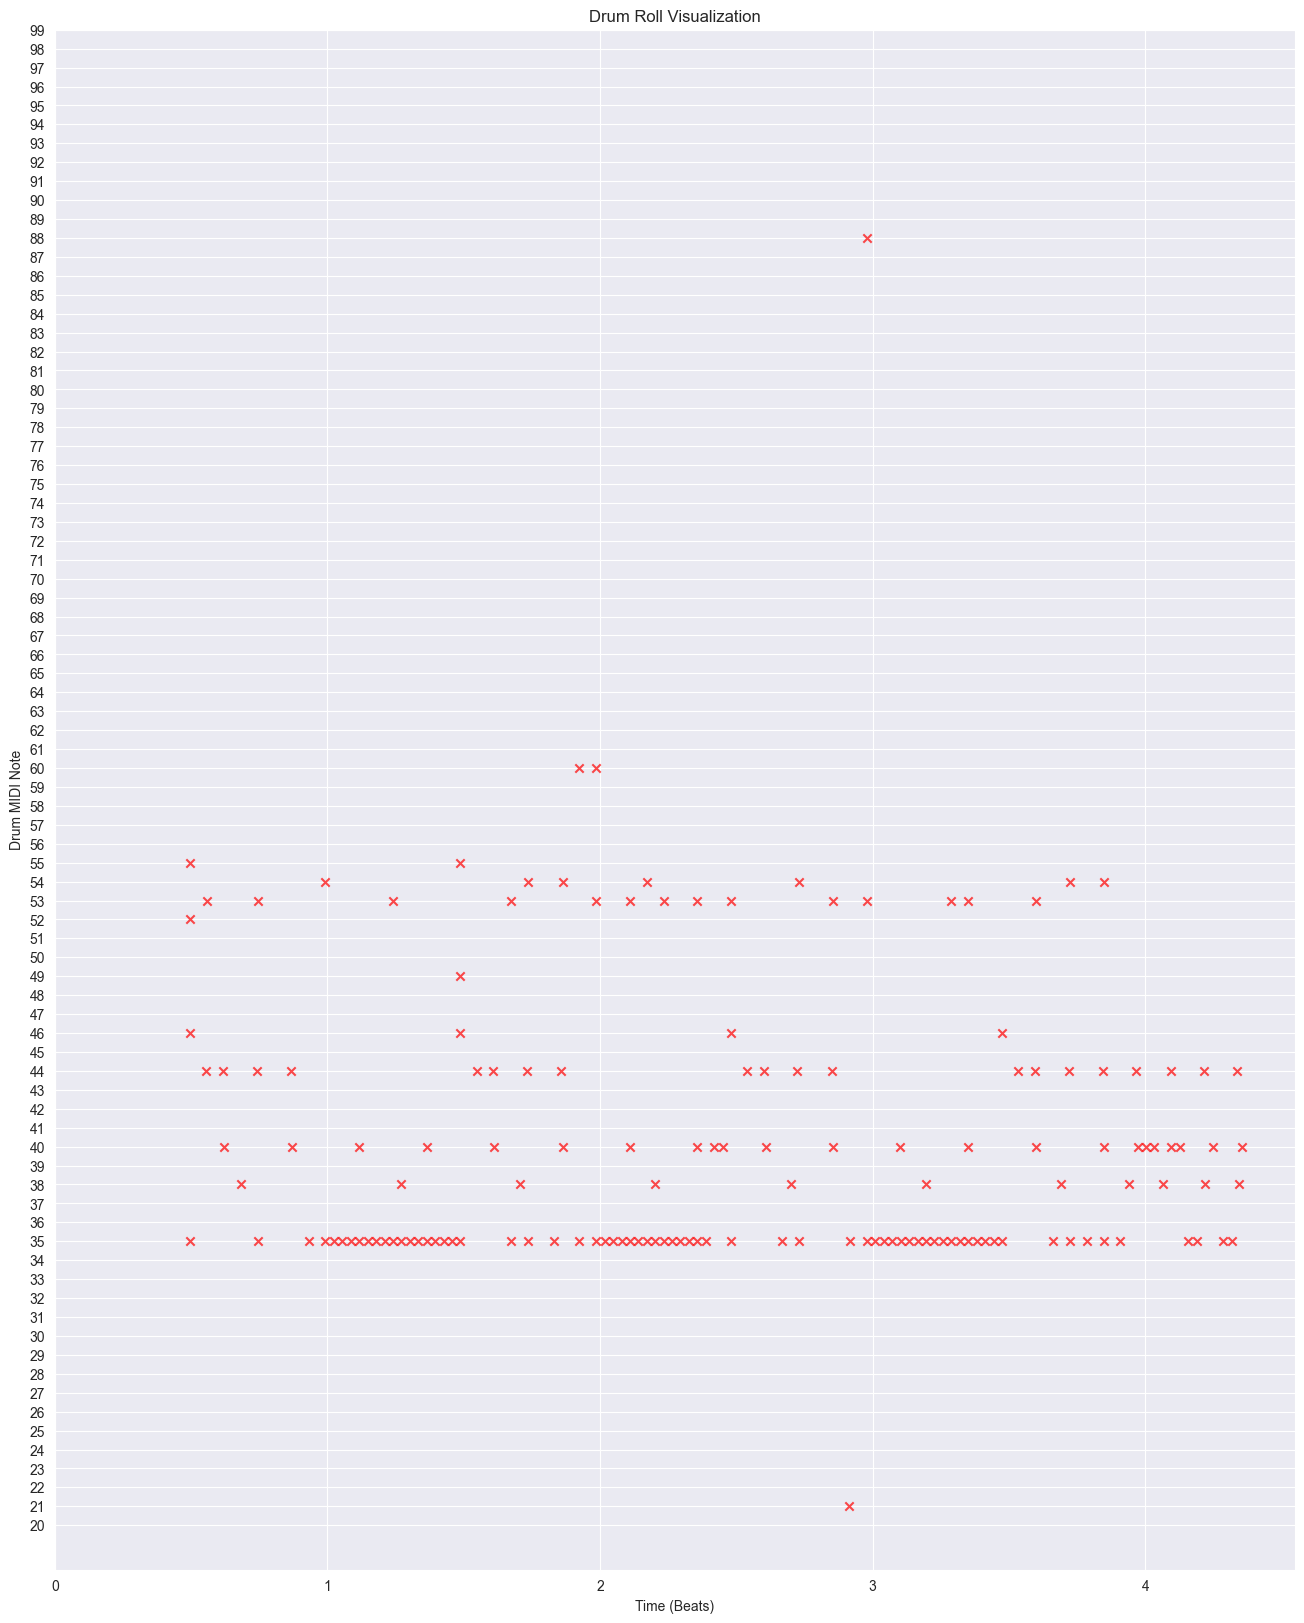

In [82]:
plot_drum_roll(dl_mb / '1_16.mid')

standard drum midi pitches: 35-81
-> others maybe defined above or below

## Groove Dataset

## Additional Datasets